In [ ]:
print("🔧 Configurando PyTorch y librerías base...")

!pip install -q opencv-python-headless Pillow torch torchvision torchaudio tqdm scikit-learn matplotlib
!pip install -q wandb
!pip install kaggle -q


🔧 Configurando PyTorch y librerías base...


Montar google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive/kaggle'
os.environ['WANDB_API_KEY'] = ''

Descarga del dataset de la plataforma de kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("javiersarango/coffee-roast-agtron-scale-dataset")

print("Path to dataset files:", path)

100%|██████████| 14.3G/14.3G [02:44<00:00, 93.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/javiersarango/coffee-roast-agtron-scale-dataset/versions/1


# 1. IMPORTACIONES Y CONFIGURACIÓN GLOBAL

In [ ]:
import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import time
import wandb

# --- Optimizaciones ---
from joblib import Parallel, delayed
import multiprocessing

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as F

# --- Importaciones para optimización ---
from torch.cuda.amp import autocast, GradScaler
import wandb
# ---------------------------------------------

# --- Librerías de utilidades ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score



## 1B. VARIABLES GLOBALES Y SEMILLAS

In [ ]:
SEED = 42
IMG_SIZE = (128, 128)
CHANNELS = 3 # Eentrada de 3 canales (L*, a*, b*)
TEST_SPLIT = 0.10
VALIDATION_SPLIT = 0.20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(multiprocessing.cpu_count(), 4) # Usar 4 cores o los disponibles para multiprocesamiento

# === PARÁMETROS PARA U-NET ===
BATCH_SIZE_UNET = 32
EPOCHS_UNET = 50
LR_UNET = 0.001
EARLY_STOP_PATIENCE = 5
# ==========================================

# === Parámetros para la CNN ===
BATCH_SIZE_CNN = 32
EPOCHS_CNN = 50
LR_CNN = 1e-4
CNN_EARLY_STOP_PATIENCE = 10

# --- Configurar semillas ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Rutas ---
KAGGLE_INPUT_ROOT = '/root/.cache/kagglehub/datasets/javiersarango/coffee-roast-agtron-scale-dataset/versions/1'
BASE_DIR = os.path.join(KAGGLE_INPUT_ROOT, 'DatasetCoffee')
OUTPUT_DIR = '/content/drive/MyDrive/Resultados2/'
MASK_DIR = os.path.join(OUTPUT_DIR, 'masks/') # Para máscaras GT .png
# --- Rutas para .npy ---
LAB_IMG_DIR = os.path.join(OUTPUT_DIR, 'images_lab_npy/') # Para imágenes Lab
SEG_LAB_NPY_DIR = os.path.join(OUTPUT_DIR, 'segmented_lab_npy/') # Para Lab segmentadas
# -----------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(LAB_IMG_DIR, exist_ok=True)
os.makedirs(SEG_LAB_NPY_DIR, exist_ok=True)

print(f"✅ Dispositivo de entrenamiento: {DEVICE}")
print(f"✅ Núcleos para DataLoader: {NUM_WORKERS}")
print(f"✅ Enfoque de Colorimetría: CIELAB")



✅ Dispositivo de entrenamiento: cuda
✅ Núcleos para DataLoader: 2
✅ Enfoque de Colorimetría: CIELAB


## 1C. TRANSFORMACIONES CIELAB (Se usará en Pre-procesamiento)

In [ ]:
class ConvertToLab(object):
    """
    Convierte una imagen PIL (RGB) a un tensor Lab.
    Se usará solo para pre-procesamiento y para inferencia visual.
    """
    def __call__(self, img_pil_rgb):
        img_np_rgb = np.array(img_pil_rgb)
        img_np_lab = cv2.cvtColor(img_np_rgb, cv2.COLOR_RGB2Lab)
        return F.to_tensor(img_np_lab) # (C, H, W) [0, 1]

# Normalización para Lab [0, 1]: (valor - 0.5) / 0.5 = valor*2 - 1
LAB_NORMALIZE = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

print("✅ Definida la transformación a CIELAB y la normalización.")



✅ Definida la transformación a CIELAB y la normalización.


## 1D. FUNCIONES Y MODELOS BASE

In [ ]:
# ---Checkpoint de U-Net ---
def save_checkpoint_unet(model, optimizer, scaler, epoch, best_loss, path):
    """Guarda un checkpoint completo de U-Net para reanudar (incluye AMP)."""
    print(f"  -> Guardando nuevo mejor modelo U-Net en {path} (Val Loss: {best_loss:.4f})")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_val_loss': best_loss,
    }, path)

# --- Checkpoint de CNN (Simple) ---
def save_checkpoint(model, path, best_loss=None):
    """Guarda el estado del modelo para PyTorch (versión simple para CNN)."""
    print(f"  -> Guardando nuevo mejor modelo CNN en {path} (Val Loss: {best_loss:.4f})")
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_val_loss': best_loss,
    }, path)


# --- Definición de Modelos (UNet y SimpleCNN) ---
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.e1 = conv_block(in_channels, 16); self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.e2 = conv_block(16, 32)
        self.bridge = conv_block(32, 64)
        self.up_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.d1 = conv_block(32 + 32, 32)
        self.up_conv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.d2 = conv_block(16 + 16, 16)
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)


    def forward(self, x):
        c1 = self.e1(x); p1 = self.maxpool(c1)
        c2 = self.e2(p1); p2 = self.maxpool(c2)
        c3 = self.bridge(p2)
        u4 = self.up_conv1(c3); u4 = torch.cat([u4, c2], dim=1); c4 = self.d1(u4)
        u5 = self.up_conv2(c4); u5 = torch.cat([u5, c1], dim=1); c5 = self.d2(u5)
        return self.out(c5)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(CHANNELS, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print("✅ Modelos U-Net y SimpleCNN definidos.")

✅ Modelos U-Net y SimpleCNN definidos.


## 2A. GENERACIÓN DE GT AUTOMÁTICO (Máscaras en Canal L*)

In [ ]:
def create_mask_gt(image_path, mask_path):
    """Genera la máscara binaria (GT) usando Umbral de Otsu en el canal L*."""
    try:
        image_bgr = cv2.imread(image_path)
        if image_bgr is None: return False
        image_lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2Lab)
        l_channel, _, _ = cv2.split(image_lab)
        _, binary_mask = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = np.ones((5, 5), np.uint8)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        cv2.imwrite(mask_path, binary_mask)
        return True
    except Exception as e:
        return False

def get_mask_path(img_original_path):
    """Genera la ruta de la máscara estandarizando la extensión a .png"""
    base_name = os.path.splitext(os.path.basename(img_original_path))[0]
    return os.path.join(MASK_DIR, base_name + '.png')

# --- Listar imágenes y crear el DataFrame ---
all_files, labels = [], []
file_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.jfif')
for class_name in os.listdir(BASE_DIR):
    class_path = os.path.join(BASE_DIR, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.endswith(file_extensions):
                all_files.append(os.path.join(class_path, img_name))
                labels.append(class_name)

df = pd.DataFrame({'path': all_files, 'class': labels})
df['mask_path'] = df['path'].apply(get_mask_path)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True) # Mezclar

# --- OPTIMIZACIÓN: Generación de Máscaras (Paralelizada con zip) ---
print(f"\nGenerando máscaras GT (Otsu en L*) para {len(df)} imágenes...")
start_time = time.time()
print(f"Usando {NUM_WORKERS} núcleos de CPU para paralelizar...")

# Es más rápido iterar sobre listas/tuplas que sobre un df.iterrows()
img_paths_list = df['path'].tolist()
mask_paths_list = df['mask_path'].tolist()

results = Parallel(n_jobs=NUM_WORKERS, backend="multiprocessing")(
    delayed(create_mask_gt)(img_path, mask_path)
    for img_path, mask_path in tqdm(zip(img_paths_list, mask_paths_list), total=len(df), desc="Generando máscaras GT")
)
df['mask_created'] = results
print(f"--- Máscaras GT generadas en {time.time() - start_time:.2f} segundos ---")
# -----------------------------------------------------------


Generando máscaras GT (Otsu en L*) para 2500 imágenes...
Usando 2 núcleos de CPU para paralelizar...


Generando máscaras GT: 100%|██████████| 2500/2500 [22:52<00:00,  1.82it/s]


--- Máscaras GT generadas en 1373.33 segundos ---


## 2B. PRE-PROCESAMIENTO A .NPY

In [ ]:
def get_npy_path(img_original_path):
    """Convierte la ruta original a la ruta del .npy pre-procesado."""
    relative_path = os.path.relpath(img_original_path, BASE_DIR)
    # Reemplaza separadores de directorio y extensiones
    save_name = relative_path.replace(os.sep, '_')
    save_name = os.path.splitext(save_name)[0] + '.npy'
    return os.path.join(LAB_IMG_DIR, save_name)

def process_and_save_lab(img_path, npy_save_path):
    """Carga, redimensiona, convierte a Lab y guarda como .npy"""
    try:
        # 1. Cargar RGB
        img_rgb_pil = Image.open(img_path).convert('RGB')
        # 2. Redimensionar
        img_rgb_pil = img_rgb_pil.resize(IMG_SIZE, Image.Resampling.BILINEAR)
        # 3. Convertir a Lab (NumPy uint8)
        img_np_rgb = np.array(img_rgb_pil)
        img_np_lab = cv2.cvtColor(img_np_rgb, cv2.COLOR_RGB2Lab) # (128, 128, 3)
        # 4. Guardar como .npy
        np.save(npy_save_path, img_np_lab)
        return True
    except Exception as e:
        print(f"Error procesando {img_path}: {e}")
        return False

# --- Añadir rutas .npy al DataFrame ---
df['npy_path'] = df['path'].apply(get_npy_path)
npy_paths_list = df['npy_path'].tolist()

print(f"\nGenerando archivos .npy (CIELAB) para {len(df)} imágenes...")
start_time = time.time()

results_npy = Parallel(n_jobs=NUM_WORKERS, backend="multiprocessing")(
    delayed(process_and_save_lab)(img_path, npy_path)
    for img_path, npy_path in tqdm(zip(img_paths_list, npy_paths_list), total=len(df), desc="Pre-procesando a .npy")
)
df['npy_created'] = results_npy
print(f"--- Archivos .npy generados en {time.time() - start_time:.2f} segundos ---")
# ---------------------------------------------------------------------------------


Generando archivos .npy (CIELAB) para 2500 imágenes...


Pre-procesando a .npy: 100%|██████████| 2500/2500 [13:23<00:00,  3.11it/s]


--- Archivos .npy generados en 804.47 segundos ---


## 2C. DIVISIÓN DEL DATASET

In [ ]:
# --- División del Dataset (Train/Val/Test) ---
df_train_val, df_test = train_test_split(
    df, test_size=TEST_SPLIT, stratify=df['class'], random_state=SEED
)
val_proportion = VALIDATION_SPLIT / (1 - TEST_SPLIT)
df_train, df_val = train_test_split(
    df_train_val, test_size=val_proportion, stratify=df_train_val['class'], random_state=SEED
)

# --- Filtrar usando la columna booleana ---
# Solo usamos imágenes donde pudimos crear la máscara Y el .npy
df_train_valid = df_train[df_train['mask_created'] & df_train['npy_created']].reset_index(drop=True)

df_val_valid = df_val[df_val['mask_created'] & df_val['npy_created']].reset_index(drop=True)
# El df_test usará todos los .npy creados
df_test_valid = df_test[df_test['npy_created']].reset_index(drop=True)

failed_masks = len(df) - df['mask_created'].sum()
failed_npy = len(df) - df['npy_created'].sum()
if failed_masks > 0: print(f"⚠️ Advertencia: No se pudieron generar {failed_masks} máscaras.")
if failed_npy > 0: print(f"⚠️ Advertencia: No se pudieron generar {failed_npy} .npy.")

# Crear mapas de clases y columna numérica
class_to_idx = {name: i for i, name in enumerate(sorted(df['class'].unique()))}
idx_to_class = {i: name for name, i in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)

# Añadir 'label' numérica a todos los dataframes
df_train_valid['label'] = df_train_valid['class'].map(class_to_idx)
df_val_valid['label'] = df_val_valid['class'].map(class_to_idx)
df_test_valid['label'] = df_test_valid['class'].map(class_to_idx)


print("\n--- Resumen del Dataset ---")
print(f"Total: {len(df)} | Train (U-Net): {len(df_train_valid)} | Val (U-Net): {len(df_val_valid)} | Test (CNN): {len(df_test_valid)}")
print(f"Total de clases: {NUM_CLASSES}")


--- Resumen del Dataset ---
Total: 2500 | Train (U-Net): 1749 | Val (U-Net): 501 | Test (CNN): 250
Total de clases: 5


# 3. ENTRENAMIENTO U-NET (OPTIMIZADO con .npy y AMP)

In [ ]:
# --- Transformaciones U-Net (solo máscara) ---
# La imagen ya está redimensionada y en Lab (.npy)
TRANSFORM_UNET_MASK = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=F.InterpolationMode.NEAREST),
    transforms.ToTensor()
])
# -------------------------------------------------------------

# --- CoffeeSegDataset ---
class CoffeeSegDataset(Dataset):
    """
    Dataset para U-Net.
    Carga .npy (Lab) y .png (Mask) directamente.
    Aplica aumentación en Tensores.
    """
    def __init__(self, df, augmentation=False):
        self.augmentation = augmentation
        # Guardamos las listas para acceso súper rápido (evita .iloc)
        self.npy_paths = df['npy_path'].tolist()
        self.mask_paths = df['mask_path'].tolist()

    def __len__(self):
        return len(self.npy_paths)

    def __getitem__(self, idx):
        # 1. Cargar imagen Lab
        # Los .npy ya están en (128, 128, 3) y en uint8 [0-255]
        img_np_lab = np.load(self.npy_paths[idx])

        # 2. Cargar máscara
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # 3. Convertir a Tensor antes de aumentar
        # (H,W,C) -> (C,H,W) y [0, 255] -> [0, 1]
        image_tensor = F.to_tensor(img_np_lab)
        # (H,W) -> (1,H,W) y [0, 255] -> [0, 1]
        mask_tensor = TRANSFORM_UNET_MASK(mask)

        # 4. Aumentación (sincronizada) sobre Tensores
        if self.augmentation:
            if random.random() > 0.5:
                image_tensor = F.hflip(image_tensor)
                mask_tensor = F.hflip(mask_tensor)
            if random.random() > 0.5:
                image_tensor = F.vflip(image_tensor)
                mask_tensor = F.vflip(mask_tensor)

        # 5. Normalizar imagen y binarizar máscara
        image_tensor = LAB_NORMALIZE(image_tensor)
        mask_tensor = (mask_tensor > 0.5).float()

        return image_tensor, mask_tensor
# -----------------------------------------------------------------

# Función para calcular IoU y Dice Coefficient
def dice_iou_metrics(pred, target):
    smooth = 1e-6
    pred = pred.view(-1); target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    dice_score = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    iou_score = (intersection + smooth) / (union + smooth)
    return dice_score, iou_score


# --- DataLoader ---
print(f"Creando DataLoaders U-Net OPTIMIZADOS (CIELAB): Batch Size={BATCH_SIZE_UNET}, Workers={NUM_WORKERS}")
train_dataset = CoffeeSegDataset(df_train_valid, augmentation=True)
val_dataset = CoffeeSegDataset(df_val_valid, augmentation=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE_UNET, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE_UNET, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2
)
# -----------------------------------------------------------

# --- Bucle de Entrenamiento U-Net (con AMP y W&B) ---
def train_unet(model, train_loader, val_loader, criterion, optimizer, scaler, epochs, device, model_path, patience):
    history = defaultdict(lambda: defaultdict(list))
    best_val_loss = float('inf')
    patience_counter = 0
    start_epoch = 0

    # --- Lógica para reanudar entrenamiento ---
    if os.path.exists(model_path):
        try:
            print(f"Cargando checkpoint existente desde {model_path}...")
            checkpoint = torch.load(model_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_loss = checkpoint['best_val_loss']
            print(f"Reanudando desde la época {start_epoch+1}. Mejor Val Loss anterior: {best_val_loss:.4f}")
        except Exception as e:
            print(f"Error al cargar checkpoint, empezando de cero. ({e})")

    print(f"Iniciando entrenamiento U-Net desde época {start_epoch+1} por {epochs} épocas (Paciencia={patience})...")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss, train_dice, train_iou = 0.0, 0.0, 0.0
        loop_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for images, masks in loop_train:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()

            # --- AMP: autocast (Train) ---
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            # ---------------------------

            # --- AMP: scaler ---
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # -------------------

            train_loss += loss.item() * images.size(0)
            with torch.no_grad(): # Métricas fuera del grafo de cómputo
                preds = (torch.sigmoid(outputs) > 0.5).float()
                dice, iou = dice_iou_metrics(preds, masks)
                train_dice += dice.item() * images.size(0)
                train_iou += iou.item() * images.size(0)
                loop_train.set_postfix(loss=loss.item(), dice=dice.item())

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_dice = train_dice / len(train_loader.dataset)
        epoch_train_iou = train_iou / len(train_loader.dataset)

        # --- VALIDACIÓN (con autocast) ---
        model.eval()
        val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
        loop_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for images, masks in loop_val:
                images, masks = images.to(device), masks.to(device)

                # --- AMP: autocast (Val) ---
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                # -------------------------

                val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                dice, iou = dice_iou_metrics(preds, masks)
                val_dice += dice.item() * images.size(0)
                val_iou += iou.item() * images.size(0)
                loop_val.set_postfix(loss=loss.item(), dice=dice.item())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_dice = val_dice / len(val_loader.dataset)
        epoch_val_iou = val_iou / len(val_loader.dataset)

        print(f'Epoch {epoch+1}/{epochs}: Loss: {epoch_train_loss:.4f} (V:{epoch_val_loss:.4f}) | Dice: {epoch_train_dice:.4f} (V:{epoch_val_dice:.4f})')

        # --- W&B: Loggear métricas ---
        wandb.log({
            "epoch": epoch,
            "unet_train_loss": epoch_train_loss, "unet_val_loss": epoch_val_loss,
            "unet_train_dice": epoch_train_dice, "unet_val_dice": epoch_val_dice,
            "unet_train_iou": epoch_train_iou,   "unet_val_iou": epoch_val_iou
        })
        # -----------------------------

        history['loss']['train'].append(epoch_train_loss); history['loss']['val'].append(epoch_val_loss)
        history['dice']['train'].append(epoch_train_dice); history['dice']['val'].append(epoch_val_dice)
        history['iou']['train'].append(epoch_train_iou); history['iou']['val'].append(epoch_val_iou)

        # --- Early Stopping y Checkpoint Completo ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            save_checkpoint_unet(model, optimizer, scaler, epoch, best_val_loss, model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early Stopping activado (paciencia={patience})!")
                break

    print(f"Entrenamiento finalizado. Mejor Val Loss: {best_val_loss:.4f}")
    # Cargar el mejor modelo al final
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return history
# ---------------------------------------------------------------------------------

# Función de Visualización (sin cambios)
def plot_segmentation_history(history, title_suffix):
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history['loss']['train'], label='Pérdida (Train)', color='blue')
    plt.plot(history['loss']['val'], label='Pérdida (Validation)', color='red')
    plt.title(f'Curvas de Pérdida {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 2)
    plt.plot(history['dice']['train'], label='Dice (Train)', color='green')
    plt.plot(history['dice']['val'], label='Dice (Validation)', color='darkgreen')
    plt.title(f'Dice Coefficient {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Dice'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 3)
    plt.plot(history['iou']['train'], label='IoU (Train)', color='orange')
    plt.plot(history['iou']['val'], label='IoU (Validation)', color='darkorange')
    plt.title(f'IoU {title_suffix}'); plt.xlabel('Época'); plt.ylabel('IoU'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

# --- Iniciar W&B (U-Net) ---

wandb.init(
    project="tesis-cafe-segmentacion", # Nombre del proyecto
    name=f"unet_bs{BATCH_SIZE_UNET}_lr{LR_UNET}_epo50_img{IMG_SIZE[0]}", #Nombre del experimento
    config={
        "learning_rate": LR_UNET, "epochs": EPOCHS_UNET,
        "batch_size": BATCH_SIZE_UNET, "img_size": IMG_SIZE,
        "architecture": "U-Net Light (16-64)", "device": str(DEVICE)
    },
    reinit=True # Permite reiniciar si ya existía uno
)
# ------------------------------------

# --- Iniciar entrenamiento U-Net ---
unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
unet_model_path = os.path.join(OUTPUT_DIR, 'unet_segmentation_model_best_exp2.pth')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=LR_UNET)
# Inicializar el Scaler de AMP
scaler = GradScaler()
wandb.watch(unet_model, log="all") monitorea gradientes

print("\n" + "="*70); print("ENTRENANDO U-NET (CIELAB) [OPTIMIZADO CON .NPY Y AMP]"); print("="*70)
start_time = time.time()

unet_history_nested = train_unet(
    unet_model, train_loader, val_loader, criterion, optimizer,
    scaler=scaler,                  # <-- Pasar el scaler
    epochs=EPOCHS_UNET,
    device=DEVICE,
    model_path=unet_model_path,
    patience=EARLY_STOP_PATIENCE
)
print(f"--- Entrenamiento U-Net completado en {time.time() - start_time:.2f} segundos ---")
wandb.finish() # Marcar el "run" de U-Net como completado

Creando DataLoaders U-Net OPTIMIZADOS (CIELAB): Batch Size=32, Workers=2


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: javier-a-sarango (javier-a-sarango-universidad-nacional-de-loja) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/tmp/ipython-input-3187126522.py:233: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



ENTRENANDO U-NET (CIELAB) [OPTIMIZADO CON .NPY Y AMP]
Cargando checkpoint existente desde /content/drive/MyDrive/Resultados2/unet_segmentation_model_best_exp2.pth...
Reanudando desde la época 29. Mejor Val Loss anterior: 0.0606
Iniciando entrenamiento U-Net desde época 29 por 50 épocas (Paciencia=5)...


Epoch 29/50 [Train]:   0%|          | 0/55 [00:00<?, ?it/s]/tmp/ipython-input-3187126522.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 29/50 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipython-input-3187126522.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch 30/50: Loss: 0.0618 (V:0.0625) | Dice: 0.9725 (V:0.9715)


Epoch 31/50: Loss: 0.0622 (V:0.0606) | Dice: 0.9721 (V:0.9731)


Epoch 32/50: Loss: 0.0602 (V:0.0609) | Dice: 0.9732 (V:0.9725)


Epoch 33/50: Loss: 0.0602 (V:0.0613) | Dice: 0.9732 (V:0.9722)
  -> Early Stopping activado (paciencia=5)!
Entrenamiento finalizado. Mejor Val Loss: 0.0606
--- Entrenamiento U-Net completado en 1040.05 segundos ---


epoch,▁▃▅▆█
unet_train_dice,▅▃▁██
unet_train_iou,▅▃▁██
unet_train_loss,▅▇█▁▁
unet_val_dice,▆▁█▆▄
unet_val_iou,▆▁█▆▄
unet_val_loss,▆█▁▂▄
epoch,32
unet_train_dice,0.97319
unet_train_iou,0.94782
unet_train_loss,0.06017



GRÁFICAS DE ENTRENAMIENTO U-NET


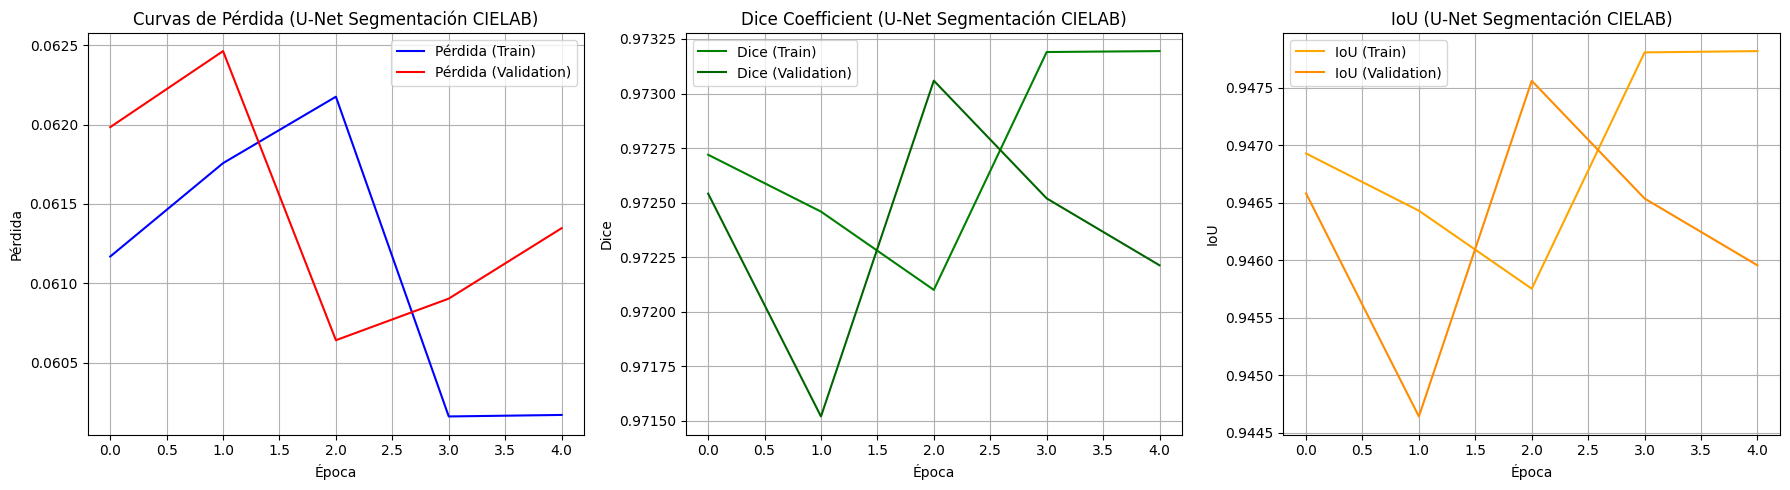

In [ ]:
# 🎯 VISUALIZACIÓN INMEDIATA DE U-NET
print("\n" + "="*70); print("GRÁFICAS DE ENTRENAMIENTO U-NET"); print("="*70)
plot_segmentation_history(unet_history_nested, '(U-Net Segmentación CIELAB)')

# 4. POST-PROCESAMIENTO: GENERACIÓN DE .NPY SEGMENTADOS (OPTIMIZADO)

In [ ]:
# --- InferenceDataset (OPTIMIZADO) ---
# Carga el .npy (Lab) para el modelo y la ruta original para el mapeo
class InferenceDataset(Dataset):
    """
    Dataset optimizado para inferencia:
    - Carga .npy Lab pre-procesado para el modelo
    - Devuelve la ruta original y la clase para el mapeo
    """
    def __init__(self, df, img_size):
        self.img_size = img_size
        self.original_paths = df['path'].tolist()
        self.npy_paths = df['npy_path'].tolist()
        self.classes = df['class'].tolist()

        # Transformación Lab para la entrada del modelo
        self.transform_model = transforms.Compose([
            transforms.ToTensor(), # (H,W,C) [0, 255] -> (C,H,W) [0, 1]
            LAB_NORMALIZE
        ])

    def __len__(self):
        return len(self.original_paths)

    def __getitem__(self, idx):
        npy_path = self.npy_paths[idx]
        original_path = self.original_paths[idx]
        img_class = self.classes[idx]

        try:
            img_np_lab = np.load(npy_path)
            img_tensor = self.transform_model(img_np_lab)
        except Exception as e:
            img_tensor = torch.zeros((CHANNELS, self.img_size[0], self.img_size[1]))

        # Devuelve el tensor Lab (para U-Net) y la data original (para guardar)
        # Devolvemos el tensor Lab NO normalizado [0,1]
        # para aplicar la máscara antes de guardar.
        try:
            img_np_lab_unnormalized = np.load(npy_path) # (H,W,C) [0-255]
        except Exception:
            img_np_lab_unnormalized = np.zeros((self.img_size[0], self.img_size[1], CHANNELS), dtype=np.uint8)

        return img_tensor, img_np_lab_unnormalized, original_path, img_class
# -------------------------------------------------------------------

In [ ]:
# Cargar el mejor modelo U-Net
unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
checkpoint = torch.load(unet_model_path, map_location=DEVICE)
unet_model.load_state_dict(checkpoint['model_state_dict'])
unet_model.eval()
print("\n✅ Modelo U-Net (CIELAB) cargado para segmentación.")

# Combinar todos los dataframes para inferencia
df_all_seg = pd.concat([df_train_valid, df_val_valid, df_test_valid]).drop_duplicates(subset=['path']).reset_index(drop=True)

INFERENCE_BATCH_SIZE = BATCH_SIZE_CNN # 32
inference_dataset = InferenceDataset(df_all_seg, IMG_SIZE)
inference_loader = DataLoader(
    inference_dataset, batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\nGenerando archivos .npy segmentados (Inferencia por Lotes, BS={INFERENCE_BATCH_SIZE})...")
start_time = time.time()
path_map = {} # Mapeará la ruta original a la NUEVA ruta .npy segmentada

with torch.no_grad():
    for img_tensors, img_lab_unnormalized, img_paths, img_classes in tqdm(inference_loader, desc="Segmentando Lotes"):

        img_tensors = img_tensors.to(DEVICE) # [B, 3, 128, 128] (Lab Normalizado)

        # 1. Predicción (en batch) con AMP
        with autocast():
            # [B, 1, 128, 128], valores [0, 1]
            predicted_masks_tensor = unet_model(img_tensors)
            # Binarizar máscara en GPU
            predicted_masks_tensor = (predicted_masks_tensor > 0.5).float() # [B, 1, H, W]

        # 2. Mover a CPU para aplicar máscara sobre NumPy
        masks_batch_np = predicted_masks_tensor.cpu().numpy().transpose(0, 2, 3, 1) # [B, H, W, 1]
        img_lab_batch_np = img_lab_unnormalized.numpy() # [B, H, W, 3] (Lab uint8)

        for i in range(len(img_paths)):
            img_path = img_paths[i]; img_class = img_classes[i]
            img_lab_np = img_lab_batch_np[i]
            mask_np = masks_batch_np[i]

            # 3. Aplicar máscara (Broadcasting)
            segmented_lab_np = img_lab_np * mask_np # (H,W,3) * (H,W,1)
            segmented_lab_np = segmented_lab_np.astype(np.uint8)

            output_class_dir = os.path.join(SEG_LAB_NPY_DIR, img_class)
            os.makedirs(output_class_dir, exist_ok=True)

            img_name_seg = os.path.splitext(os.path.basename(img_path))[0] + '.npy'
            output_seg_path = os.path.join(output_class_dir, img_name_seg)

            # 4. Guardar el .npy (Lab segmentado)
            np.save(output_seg_path, segmented_lab_np)

            # 5. Mapear la ruta original a la nueva ruta .npy segmentada
            path_map[img_path] = output_seg_path

print(f"--- Imágenes .npy segmentadas generadas en {time.time() - start_time:.2f} segundos ---")
# -----------------------------------------------------------


✅ Modelo U-Net (CIELAB) cargado para segmentación.

Generando archivos .npy segmentados (Inferencia por Lotes, BS=32)...


Segmentando Lotes:   0%|          | 0/79 [00:00<?, ?it/s]/tmp/ipython-input-3774203402.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Segmentando Lotes: 100%|██████████| 79/79 [00:39<00:00,  2.00it/s]

--- Imágenes .npy segmentadas generadas en 39.58 segundos ---


In [ ]:
# --- Preparar DataFrames (Optimizado) ---
print("Mapeando rutas .npy segmentadas a DataFrames...")
# Mapea la ruta original al nuevo .npy segmentado
df_all_seg['segmented_npy_path'] = df_all_seg['path'].map(path_map)
# Mantiene la ruta .npy original (baseline)
df_all_seg['original_npy_path'] = df_all_seg['path'].apply(get_npy_path)

train_paths = set(df_train_valid['path'])
val_paths = set(df_val_valid['path'])
test_paths = set(df_test_valid['path'])

df_train_seg = df_all_seg[df_all_seg['path'].isin(train_paths)].copy()
df_val_seg = df_all_seg[df_all_seg['path'].isin(val_paths)].copy()
df_test_seg = df_all_seg[df_all_seg['path'].isin(test_paths)].copy()

# Asegurar labels
df_train_seg['label'] = df_train_seg['class'].map(class_to_idx)
df_val_seg['label'] = df_val_seg['class'].map(class_to_idx)
df_test_seg['label'] = df_test_seg['class'].map(class_to_idx)

print("✅ DataFrames de clasificación listos (apuntando a .npy).")

Mapeando rutas .npy segmentadas a DataFrames...
✅ DataFrames de clasificación listos (apuntando a .npy).


# 5. CLASIFICACIÓN (sobre CIELAB) (OPTIMIZADO con .npy y AMP)

In [ ]:
# --- Transformaciones para Tensores (leídos desde .npy) ---
TRAIN_TRANSFORMS_CLS = transforms.Compose([
    # Se aplica a Tensores (C,H,W) [0,1] leídos desde CoffeeClsDataset
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    LAB_NORMALIZE # Normalizar Lab [0,1] a [-1, 1]
])

VAL_TRANSFORMS_CLS = transforms.Compose([
    # Se aplica a Tensores (C,H,W) [0,1]
    LAB_NORMALIZE # Normalizar Lab [0,1] a [-1, 1]
])
# ----------------------------------------------------------------

# --- Dataset de Clasificación (carga .npy) ---
class CoffeeClsDataset(Dataset):
    """Dataset para la CNN (optimizado, carga .npy)"""
    def __init__(self, df, use_segmented, transform):
        self.df = df.dropna(subset=['label', 'original_npy_path'])
        if use_segmented:
            self.df = self.df.dropna(subset=['segmented_npy_path'])
            self.path_list = self.df['segmented_npy_path'].tolist()
        else:
            self.path_list = self.df['original_npy_path'].tolist()

        self.labels = self.df['label'].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, idx):
        img_path = self.path_list[idx]
        label = self.labels[idx]

        try:
            # 1. Cargar .npy (H, W, C) [0-255]
            img_np = np.load(img_path)
            # 2. Convertir a Tensor (C, H, W) [0, 1]
            image_tensor = F.to_tensor(img_np)
        except Exception as e:
            image_tensor = torch.zeros((CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

        # 3. Aplicar transformaciones (HFlip, Rotate, Normalize)
        image_tensor = self.transform(image_tensor)
        return image_tensor, label
# -----------------------------------------------------------------


# --- DataLoaders ---
print(f"\nCreando DataLoaders de Clasificación OPTIMIZADOS (CIELAB): Batch Size={BATCH_SIZE_CNN}, Workers={NUM_WORKERS}")
train_loader_seg = DataLoader(
    CoffeeClsDataset(df_train_seg, True, TRAIN_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader_seg = DataLoader(
    CoffeeClsDataset(df_val_seg, True, VAL_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
train_loader_orig = DataLoader(
    CoffeeClsDataset(df_train_seg, False, TRAIN_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader_orig = DataLoader(
    CoffeeClsDataset(df_val_seg, False, VAL_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
# -----------------------------------------------------------------

# --- Funciones de Visualización y Evaluación de Clasificación  ---
def plot_training_history_cls(history, title_suffix):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Pérdida (Train)', color='blue')
    plt.plot(history['val_loss'], label='Pérdida (Validation)', color='red')
    plt.title(f'Curvas de Pérdida {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Precisión (Train)', color='blue')
    plt.plot(history['val_accuracy'], label='Precisión (Validation)', color='red')
    plt.title(f'Curvas de Precisión {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

def evaluate_and_plot_cls(model_name, history, labels_val, preds_val, idx_to_class_map, num_classes_val):
    print(f"\n--- RESULTADOS FINALES PARA {model_name} ---")
    target_names = [idx_to_class_map[i] for i in range(num_classes_val)]
    print("\nREPORTE DE CLASIFICACIÓN (VALIDACIÓN):")
    print(classification_report(labels_val, preds_val, target_names=target_names))
    kappa = cohen_kappa_score(labels_val, preds_val)
    print(f"\nCOEFICIENTE KAPPA (VALIDACIÓN): {kappa:.4f}")
    print("\nMATRIZ DE CONFUSIÓN (VALIDACIÓN):")
    print(confusion_matrix(labels_val, preds_val))
    plot_training_history_cls(history, f'({model_name})')

# --- Bucle de Entrenamiento de CNN (con AMP) ---
def run_full_training(model_name, train_loader, val_loader, lr, epochs=EPOCHS_CNN,
                      patience=CNN_EARLY_STOP_PATIENCE,
                      visualize=False, idx_to_class_map=None, num_classes_val=None):

    print(f"\n--- INICIANDO ENTRENAMIENTO COMPLETO: {model_name} (con AMP) ---")
    model = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Añadir Scaler para AMP ---
    scaler = GradScaler()
    model_path = os.path.join(OUTPUT_DIR, f'cnn_{model_name.lower().replace(" ", "_")}_best_unet50.pth')

    history = defaultdict(list)
    best_val_loss, patience_counter = float('inf'), 0
    all_preds, all_labels = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_samples = 0.0, 0, 0
        loop_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train CLS]", leave=False)

        for images, labels in loop_train:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            # --- AMP: autocast (Train) ---
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            # ---------------------------

            # --- AMP: scaler ---
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # -------------------

            train_loss += loss.item() * images.size(0)
            with torch.no_grad():
                _, predicted = torch.max(outputs, 1); train_correct += (predicted == labels).sum().item(); total_samples += images.size(0)
                loop_train.set_postfix(loss=loss.item(), acc=(predicted == labels).sum().item() / images.size(0))

        epoch_train_loss = train_loss / total_samples
        epoch_train_accuracy = train_correct / total_samples

        model.eval()
        val_loss, val_correct, total_val_samples = 0.0, 0, 0
        all_preds_epoch, all_labels_epoch = [], []
        loop_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val CLS]", leave=False)

        with torch.no_grad():
            for images, labels in loop_val:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                # --- AMP: autocast (Val) ---
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                # -------------------------

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1); val_correct += (predicted == labels).sum().item(); total_val_samples += images.size(0)
                all_preds_epoch.extend(predicted.cpu().numpy()); all_labels_epoch.extend(labels.cpu().numpy())
                loop_val.set_postfix(loss=loss.item(), acc=(predicted == labels).sum().item() / images.size(0))

        epoch_val_loss = val_loss / total_val_samples
        epoch_val_accuracy = val_correct / total_val_samples
        all_preds = all_preds_epoch; all_labels = all_labels_epoch

        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f} (V:{epoch_val_loss:.4f}) | Train Acc: {epoch_train_accuracy:.4f} (V:{epoch_val_accuracy:.4f})')

        # --- W&B Log ---
        wandb.log({
            f"{model_name}_train_loss": epoch_train_loss, f"{model_name}_val_loss": epoch_val_loss,
            f"{model_name}_train_acc": epoch_train_accuracy, f"{model_name}_val_acc": epoch_val_accuracy,
            "epoch_cls": epoch # 'epoch' compartido
        })
        # -----------------

        history['loss'].append(epoch_train_loss); history['val_loss'].append(epoch_val_loss)
        history['accuracy'].append(epoch_train_accuracy); history['val_accuracy'].append(epoch_val_accuracy)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            # Usar la función de checkpoint simple para CNN
            save_checkpoint(model, model_path, best_val_loss)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early Stopping activado (paciencia={patience})!")
                break

    checkpoint = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    if visualize:
         evaluate_and_plot_cls(model_name, history, all_labels, all_preds, idx_to_class, NUM_CLASSES)
    return model, history, all_labels, all_preds
# -----------------------------------------------------------------


Creando DataLoaders de Clasificación OPTIMIZADOS (CIELAB): Batch Size=32, Workers=2



INICIANDO ENTRENAMIENTO DE CLASIFICACIÓN (CIELAB) [OPTIMIZADO]


/tmp/ipython-input-1783439126.py:105: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



--- INICIANDO ENTRENAMIENTO COMPLETO: Segmented CNN (U-Net) (con AMP) ---


Epoch 1/50 [Train CLS]:   0%|          | 0/55 [00:00<?, ?it/s]/tmp/ipython-input-1783439126.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50 [Val CLS]:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipython-input-1783439126.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50: Train Loss: 1.5714 (V:1.4821) | Train Acc: 0.2464 (V:0.4890)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_segmented_cnn_(u-net)_best_unet50.pth (Val Loss: 1.4821)


...

Epoch 46/50: Train Loss: 0.0466 (V:0.0319) | Train Acc: 0.9880 (V:0.9940)


Epoch 47/50: Train Loss: 0.0417 (V:0.0372) | Train Acc: 0.9880 (V:0.9920)


Epoch 48/50: Train Loss: 0.0587 (V:0.0310) | Train Acc: 0.9846 (V:0.9920)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_segmented_cnn_(u-net)_best_unet50.pth (Val Loss: 0.0310)


Epoch 49/50: Train Loss: 0.0463 (V:0.0324) | Train Acc: 0.9868 (V:0.9940)


Epoch 50/50: Train Loss: 0.0455 (V:0.0331) | Train Acc: 0.9874 (V:0.9920)

--- RESULTADOS FINALES PARA Segmented CNN (U-Net) ---

REPORTE DE CLASIFICACIÓN (VALIDACIÓN):
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       100
       Green       1.00      1.00      1.00       100
       Light       0.97      0.99      0.98       100
      Medium       0.99      0.97      0.98       101
  Overbaking       1.00      1.00      1.00       100

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501


COEFICIENTE KAPPA (VALIDACIÓN): 0.9900

MATRIZ DE CONFUSIÓN (VALIDACIÓN):
[[100   0   0   0   0]
 [  0 100   0   0   0]
 [  0   0  99   1   0]
 [  0   0   3  98   0]
 [  0   0   0   0 100]]


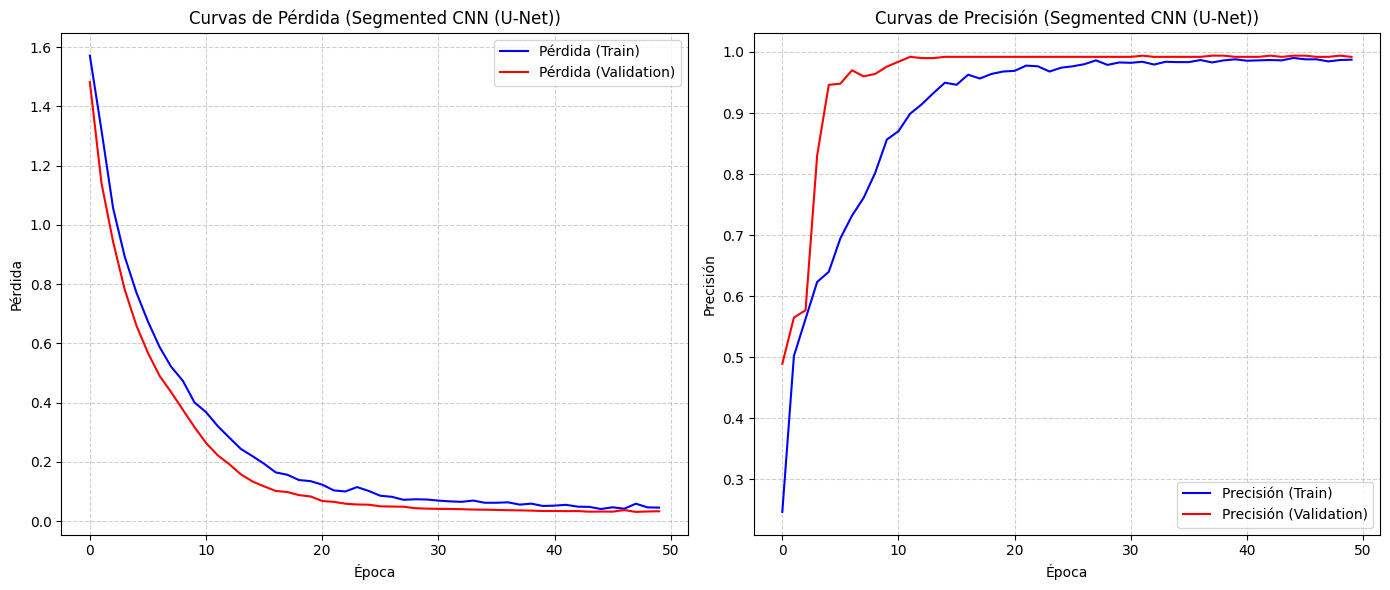

/tmp/ipython-input-1783439126.py:105: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



--- INICIANDO ENTRENAMIENTO COMPLETO: Original CNN (Baseline) (con AMP) ---


Epoch 1/50 [Train CLS]:   0%|          | 0/55 [00:00<?, ?it/s]/tmp/ipython-input-1783439126.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50 [Val CLS]:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipython-input-1783439126.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50: Train Loss: 1.5902 (V:1.5557) | Train Acc: 0.2190 (V:0.3952)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_original_cnn_(baseline)_best_unet50.pth (Val Loss: 1.5557)


Epoch 2/50: Train Loss: 1.4943 (V:1.3787) | Train Acc: 0.3505 (V:0.4451)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_original_cnn_(baseline)_best_unet50.pth (Val Loss: 1.3787)


...

Epoch 46/50: Train Loss: 0.0573 (V:0.0494) | Train Acc: 0.9823 (V:0.9920)


Epoch 47/50: Train Loss: 0.0619 (V:0.0453) | Train Acc: 0.9857 (V:0.9920)


Epoch 48/50: Train Loss: 0.0522 (V:0.0434) | Train Acc: 0.9868 (V:0.9900)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_original_cnn_(baseline)_best_unet50.pth (Val Loss: 0.0434)


Epoch 49/50: Train Loss: 0.0545 (V:0.0444) | Train Acc: 0.9851 (V:0.9920)


Epoch 50/50: Train Loss: 0.0514 (V:0.0432) | Train Acc: 0.9857 (V:0.9900)
  -> Guardando nuevo mejor modelo CNN en /content/drive/MyDrive/Resultados2/cnn_original_cnn_(baseline)_best_unet50.pth (Val Loss: 0.0432)

--- RESULTADOS FINALES PARA Original CNN (Baseline) ---

REPORTE DE CLASIFICACIÓN (VALIDACIÓN):
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       100
       Green       1.00      1.00      1.00       100
       Light       0.96      0.99      0.98       100
      Medium       0.99      0.96      0.97       101
  Overbaking       1.00      1.00      1.00       100

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501


COEFICIENTE KAPPA (VALIDACIÓN): 0.9875

MATRIZ DE CONFUSIÓN (VALIDACIÓN):
[[100   0   0   0   0]
 [  0 100   0   0   0]
 [  0   0  99   1   0]
 [  0   0   4  97   0]
 [  0   0   0   0 100]]


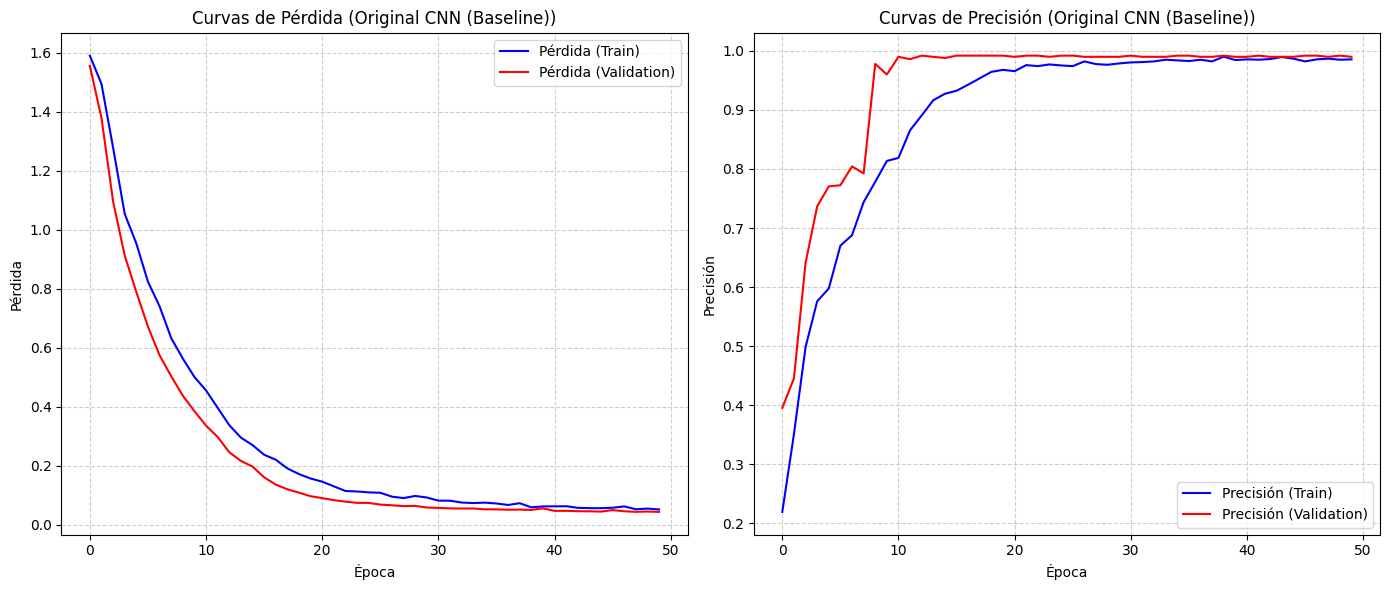

Original CNN (Baseline)_train_acc,▁▃▃▄▄▅▆▆▆▇▇▇▇▇██████████████████████████
Original CNN (Baseline)_train_loss,██▇▆▅▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Original CNN (Baseline)_val_acc,▁▂▄▅▅▆▆█████████████████████████████████
Original CNN (Baseline)_val_loss,█▇▆▅▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Segmented CNN (U-Net)_train_acc,▁▃▄▅▅▆▆▆▇▇▇█████████████████████████████
Segmented CNN (U-Net)_train_loss,█▇▅▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Segmented CNN (U-Net)_val_acc,▁▂▂▆▇███████████████████████████████████
Segmented CNN (U-Net)_val_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch_cls,▁▂▂▂▂▃▃▃▃▄▄▅▅▆▆▇▇▇▇▇▁▂▂▂▂▂▃▃▃▃▄▅▅▅▆▆▇▇██
Original CNN (Baseline)_train_acc,0.98571
Original CNN (Baseline)_train_loss,0.05143


In [ ]:
# --- Entrenar Experimentos y Visualizar ---
print("\n" + "="*70); print("INICIANDO ENTRENAMIENTO DE CLASIFICACIÓN (CIELAB) [OPTIMIZADO]"); print("="*70)

# ---  Iniciar W&B (Clasificación) ---
wandb.init(
    project="tesis-cafe-clasificacion", # Proyecto de clasificación
    name=f"cnn_bs{BATCH_SIZE_CNN}_lr{LR_CNN}_unet50epo_img{IMG_SIZE[0]}", #Nombre del experimento
    config={
        "learning_rate": LR_CNN, "epochs": EPOCHS_CNN,
        "batch_size": BATCH_SIZE_CNN, "device": str(DEVICE)
    },
    reinit=True
)
# ----------------------------------------------------
# 1. Segmented CNN (U-Net)
model_seg, history_seg, labels_val_seg, preds_val_seg = run_full_training(
    'Segmented CNN (U-Net)',
    train_loader_seg, val_loader_seg, LR_CNN,
    epochs=EPOCHS_CNN, patience=CNN_EARLY_STOP_PATIENCE,
    visualize=True, idx_to_class_map=idx_to_class, num_classes_val=NUM_CLASSES
)
# 2. Original CNN (Baseline)
model_orig, history_orig, labels_val_orig, preds_val_orig = run_full_training(
    'Original CNN (Baseline)',
    train_loader_orig, val_loader_orig, LR_CNN,
    epochs=EPOCHS_CNN, patience=CNN_EARLY_STOP_PATIENCE,
    visualize=True, idx_to_class_map=idx_to_class, num_classes_val=NUM_CLASSES
)

wandb.finish() # Terminar el run de W&B

# 6. COMPARACIÓN FINAL


COMPARACIÓN FINAL DE MÉTRICAS DE VALIDACIÓN (CIELAB)


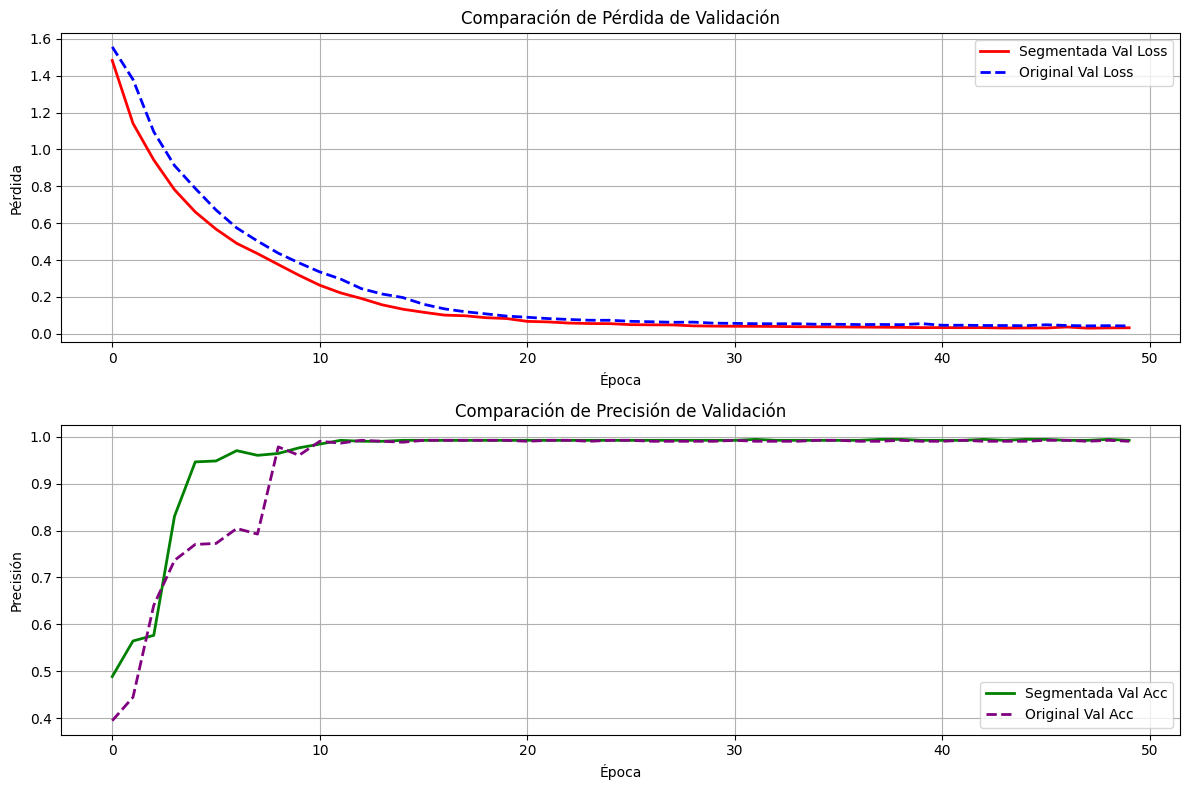


FIN DEL EXPERIMENTO. Todas las métricas han sido visualizadas. ✅


In [ ]:
print("\n" + "="*70); print("COMPARACIÓN FINAL DE MÉTRICAS DE VALIDACIÓN (CIELAB)"); print("="*70)
plt.figure(figsize=(12, 8))

# Pérdida
plt.subplot(2, 1, 1)
plt.plot(history_seg['val_loss'], label='Segmentada Val Loss', linestyle='-', color='red', linewidth=2)
plt.plot(history_orig['val_loss'], label='Original Val Loss', linestyle='--', color='blue', linewidth=2)
plt.title('Comparación de Pérdida de Validación')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True)

# Precisión
plt.subplot(2, 1, 2)
plt.plot(history_seg['val_accuracy'], label='Segmentada Val Acc', linestyle='-', color='green', linewidth=2)
plt.plot(history_orig['val_accuracy'], label='Original Val Acc', linestyle='--', color='purple', linewidth=2)
plt.title('Comparación de Precisión de Validación')
plt.xlabel('Época'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

print("\nFIN DEL EXPERIMENTO. Todas las métricas han sido visualizadas. ✅")

# 7. SECCIÓN: INFERENCIA COMPARATIVA (CIELAB) (OPTIMIZADO)


INICIANDO SECCIÓN DE INFERENCIA COMPARATIVA (CIELAB)
Modelos ya en memoria y en modo eval().
✅ Modelos U-Net, CNN Segmentada y CNN Original listos en cuda.

Ejecutando inferencia comparativa en una imagen del set de Test...

Imagen de prueba: IMG_3301.JPG
Clase Real:       Dark


/tmp/ipython-input-3163585871.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-3163585871.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


--- RESULTADOS DE INFERENCIA (CIELAB) [OPTIMIZADO] ---
Pred. (Segmentada): Dark (Confianza: 0.53)
Pred. (Original):   Dark (Confianza: 1.00)


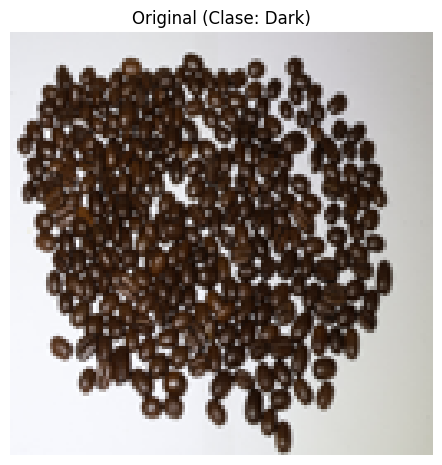


✅ Sección de Inferencia Comparativa (CIELAB) completada.

🎉 FIN DEL PIPELINE OPTIMIZADO. 🎉


In [ ]:
print("\n" + "="*70); print("INICIANDO SECCIÓN DE INFERENCIA COMPARATIVA (CIELAB)"); print("="*70)

# --- 1. Cargar los modelos ---
try:
    unet_model.eval(); model_seg.eval(); model_orig.eval()
    print("Modelos ya en memoria y en modo eval().")
except NameError:
    print("Cargando modelos desde archivo...")
    # Cargar U-Net
    unet_model_path = os.path.join(OUTPUT_DIR, 'unet_segmentation_model_best.pth')
    unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
    checkpoint_unet = torch.load(unet_model_path, map_location=DEVICE)
    unet_model.load_state_dict(checkpoint_unet['model_state_dict'])
    unet_model.eval()

    # Cargar CNN Segmentada
    cnn_seg_path = os.path.join(OUTPUT_DIR, 'cnn_segmented_cnn_(u-net)_best.pth')
    model_seg = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_cnn = torch.load(cnn_seg_path, map_location=DEVICE)
    model_seg.load_state_dict(checkpoint_cnn['model_state_dict'])
    model_seg.eval()

    # Cargar CNN Original
    cnn_orig_path = os.path.join(OUTPUT_DIR, 'cnn_original_cnn_(baseline)_best.pth')
    model_orig = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_orig = torch.load(cnn_orig_path, map_location=DEVICE)
    model_orig.load_state_dict(checkpoint_orig['model_state_dict'])
    model_orig.eval()

print(f"✅ Modelos U-Net, CNN Segmentada y CNN Original listos en {DEVICE}.")

# --- Transformación de Inferencia (desde .npy) ---
TRANSFORM_INFERENCE = transforms.Compose([
    transforms.ToTensor(), # (H,W,C) [0, 255] -> (C,H,W) [0, 1]
    LAB_NORMALIZE          # Normalizar [0, 1] -> [-1, 1]
])
# ---------------------------------------------------------

# --- 2. Funciones de Inferencia (OPTIMIZADAS) ---

def predict_pipeline_segmented(original_img_path, unet_model, cnn_model, device, img_size):
    """
    Pipeline (Inferencia por imagen):
    Carga .npy(Lab) -> U-Net(Lab) -> Máscara(Tensor) -> CNN(Lab) -> Predicción
    """
    try:
        # 1. Cargar el .NPY Lab pre-procesado
        npy_path = get_npy_path(original_img_path) # (Función de 2B)
        img_np_lab = np.load(npy_path)

        # 2. Preparar tensor para U-Net
        image_tensor_unet = TRANSFORM_INFERENCE(img_np_lab).unsqueeze(0).to(device)

    except Exception as e:
        print(f"Error al cargar el .npy: {e}"); return None, None, None

    with torch.no_grad():
        with autocast():
            # --- Paso 1: Segmentación (Tensor) ---
            mask_pred_tensor = unet_model(image_tensor_unet) # (1, 1, H, W)
            mask_binary = (mask_pred_tensor > 0.5).float()

            # --- Paso 2: Aplicar Máscara (Tensor) ---
            image_tensor_cnn = image_tensor_unet * mask_binary # (1, 3, H, W)

            # --- Paso 3: Clasificación (Tensor) ---
            outputs = cnn_model(image_tensor_cnn)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

    pred_class_idx = predicted_idx.item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Desconocido")
    pred_confidence = confidence.item()

    # --- Paso 4: Visualización ---
    try:
        image_pil = Image.open(original_img_path).convert("RGB").resize(img_size, Image.BILINEAR)
        image_cv_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
        mask_np = mask_binary.squeeze().cpu().numpy().astype(np.uint8) * 255
        mask_3_channels = cv2.cvtColor(mask_np, cv2.COLOR_GRAY2BGR)
        segmented_img_cv = cv2.bitwise_and(image_cv_bgr, mask_3_channels)
        segmented_img_pil = Image.fromarray(cv2.cvtColor(segmented_img_cv, cv2.COLOR_BGR_RGB))
    except Exception as e:
        segmented_img_pil = None # Fallback

    return pred_class_name, pred_confidence, segmented_img_pil

def predict_pipeline_original(original_img_path, cnn_model, device):
    """
    Pipeline (Inferencia por imagen):
    Carga .npy(Lab) -> CNN(Lab) -> Predicción
    """
    try:
        # 1. Cargar el .NPY Lab pre-procesado (RÁPIDO)
        npy_path = get_npy_path(original_img_path)
        img_np_lab = np.load(npy_path)

        # 2. Preparar tensor para CNN
        image_tensor_cnn = TRANSFORM_INFERENCE(img_np_lab).unsqueeze(0).to(device)

    except Exception as e:
        print(f"Error al cargar el .npy: {e}"); return None, None

    with torch.no_grad():
        with autocast():
            # --- Paso 1: Clasificación ---
            outputs = cnn_model(image_tensor_cnn)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

    pred_class_idx = predicted_idx.item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Desconocido")
    pred_confidence = confidence.item()

    return pred_class_name, pred_confidence
# -------------------------------------------------------------

# --- 3. Probar la inferencia comparativa ---
if not df_test_seg.empty:
    print("\nEjecutando inferencia comparativa en una imagen del set de Test...")

    sample_row = df_test_seg.sample(1).iloc[0]
    sample_path = sample_row['path'] # Ruta original .jpg
    actual_class = sample_row['class']

    print(f"\nImagen de prueba: {os.path.basename(sample_path)}")
    print(f"Clase Real:       {actual_class}")

    # --- Inferencia 1: Pipeline Segmentado (Lab) ---
    pred_seg_class, pred_seg_conf, segmented_image = predict_pipeline_segmented(
        sample_path, unet_model, model_seg, DEVICE, IMG_SIZE
    )

    # --- Inferencia 2: Pipeline Original (Lab) ---
    pred_orig_class, pred_orig_conf = predict_pipeline_original(
        sample_path, model_orig, DEVICE
    )

    print("--- RESULTADOS DE INFERENCIA (CIELAB) [OPTIMIZADO] ---")
    print(f"Pred. (Segmentada): {pred_seg_class} (Confianza: {pred_seg_conf:.2f})")
    print(f"Pred. (Original):   {pred_orig_class} (Confianza: {pred_orig_conf:.2f})")

    # Mostrar resultados visuales
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sample_path).resize(IMG_SIZE))
    plt.title(f"Original (Clase: {actual_class})")
    plt.axis('off')

    if segmented_image:
        plt.subplot(1, 2, 2)
        plt.imshow(segmented_image)
        plt.title(f"Segmentada (Pred: {pred_seg_class})")
        plt.axis('off')

    plt.show()

else:
    print("\nNo se encontraron imágenes en 'df_test_seg' para la inferencia de prueba.")

print("\n✅ Sección de Inferencia Comparativa (CIELAB) completada.")
print("\n🎉 FIN DEL PIPELINE OPTIMIZADO. 🎉")